# Normalization strategy study

Goal: pick a normalization strategy for the actual training pipeline, using a real run from the
**already brain-masked and cropped** production dataset
(`brain_masked_cropped_normalized_to_common_space`) -- no re-masking or re-cropping here, that's
already done by `build_dataset.py`.

Compares several candidate strategies on two axes:

1. **Robustness**: how much does each strategy's own parameters (min/max, mean/std, median/scale)
   shift when a small fraction of voxels get corrupted by a synthetic motion-spike artifact? A
   normalization step that itself gets thrown off by the very artifacts we're trying to correct
   for is a real problem -- it would make Grade 1 and Grade 6 chunks land on different effective
   scales for reasons that have nothing to do with the actual image content.
2. **Boundedness / dynamic range usage**: does the output land in a fixed, `Tanh`-compatible range
   (e.g. `[-1, 1]`) without either (a) leaving most values unbounded, or (b) saturating/flattening
   a large fraction of real signal into a handful of clipped extremes?

Both are checked quantitatively (printed tables) and visually (slice montages), then a
recommendation is made at the end based on the actual numbers from this run -- not a guess.

In [6]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_ROOT = Path("/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/faizan_motion_correction_dataset")

# Already masked + cropped by build_dataset.py -- no re-masking needed here.
RUN_PATH = DATASET_ROOT / "brain_masked_cropped_normalized_to_common_space/_subject_id_ICC103A/_referencetype_standard/_run_001_session_1_task_name_videos/sub-ICC103A_ses-1_task-videos_dir-AP_run-001_bold_mcf_corrected_flirt.nii.gz"

img = nib.load(RUN_PATH)
data = np.asarray(img.dataobj, dtype=np.float32)  # (X, Y, Z, T), already masked+cropped
brain_mask = data[..., 0] != 0  # brain footprint is identical across timepoints within a run (masked upstream)

print(f"run: {RUN_PATH.name}")
print(f"shape (X,Y,Z,T): {data.shape}")
print(f"brain voxels: {brain_mask.sum()} / {brain_mask.size} ({brain_mask.mean():.1%})")
print(f"brain-voxel intensity range (all timepoints): [{data[brain_mask].min():.2f}, {data[brain_mask].max():.2f}]")

run: sub-ICC103A_ses-1_task-videos_dir-AP_run-001_bold_mcf_corrected_flirt.nii.gz
shape (X,Y,Z,T): (60, 72, 56, 485)
brain voxels: 113172 / 241920 (46.8%)
brain-voxel intensity range (all timepoints): [0.59, 593.07]


## Candidate normalization strategies

All operate on brain-mask voxels only (background stays exactly `0`), using statistics computed
from the **whole run** (all timepoints pooled), not per-chunk -- keeps the normalization stable
regardless of how few volumes a downstream chunk has (same reasoning as the tSNR caveat from the
sanity-check script: computing robust statistics from only 5 timepoints would be noisy).

| Strategy | Formula | Target range |
|---|---|---|
| `minmax` | `(x - min) / (max - min)` | `[0, 1]` |
| `zscore` | `(x - mean) / std` | unbounded |
| `robust_p5p95` | `(x - median) / (p95 - p5)` | unbounded |
| `robust_mad` | `(x - median) / (1.4826 * MAD)` | unbounded |
| `robust_mad_clip1` | `robust_mad`, then hard-clipped to `[-1, 1]` | `[-1, 1]` |
| `robust_mad_clip3_rescale` | `robust_mad`, clipped to `[-3, 3]`, then linearly rescaled to `[-1, 1]` | `[-1, 1]` |
| `percentile_clip_minmax` | raw intensities clipped to `[p1, p99]`, then min-max to `[-1, 1]` | `[-1, 1]` |

In [ ]:
def strat_minmax(data, mask):
    x = data[mask]
    lo, hi = x.min(), x.max()
    out = np.zeros_like(data, dtype=np.float32)
    out[mask] = (x - lo) / (hi - lo)
    return out, dict(lo=float(lo), hi=float(hi))


def strat_zscore(data, mask):
    x = data[mask]
    mean, std = x.mean(), x.std()
    out = np.zeros_like(data, dtype=np.float32)
    out[mask] = (x - mean) / std
    return out, dict(mean=float(mean), std=float(std))


def strat_robust_p5p95(data, mask):
    x = data[mask]
    median = np.median(x)
    p5, p95 = np.percentile(x, [5, 95])
    scale = max(p95 - p5, 1e-8)
    out = np.zeros_like(data, dtype=np.float32)
    out[mask] = (x - median) / scale
    return out, dict(median=float(median), scale=float(scale))


def strat_robust_mad(data, mask):
    x = data[mask]
    median = np.median(x)
    mad = np.median(np.abs(x - median))
    scale = max(1.4826 * mad, 1e-8)
    out = np.zeros_like(data, dtype=np.float32)
    out[mask] = (x - median) / scale
    return out, dict(median=float(median), scale=float(scale))


def strat_robust_mad_clip1(data, mask):
    out, params = strat_robust_mad(data, mask)
    out_clipped = np.zeros_like(out)
    out_clipped[mask] = np.clip(out[mask], -1, 1)
    return out_clipped, params


def strat_robust_mad_clip3_rescale(data, mask, clip_bound=3.0):
    out, params = strat_robust_mad(data, mask)
    clipped = np.clip(out[mask], -clip_bound, clip_bound)
    rescaled = clipped / clip_bound  # [-clip_bound, clip_bound] -> [-1, 1]
    out_final = np.zeros_like(out)
    out_final[mask] = rescaled
    params["clip_bound"] = clip_bound
    return out_final, params


def strat_percentile_clip_minmax(data, mask, lo_pct=1, hi_pct=99):
    x = data[mask]
    lo, hi = np.percentile(x, [lo_pct, hi_pct])
    clipped = np.clip(x, lo, hi)
    scaled = 2 * (clipped - lo) / (hi - lo) - 1  # -> [-1, 1]
    out = np.zeros_like(data, dtype=np.float32)
    out[mask] = scaled
    return out, dict(lo=float(lo), hi=float(hi))


STRATEGIES = {
    "minmax": (strat_minmax, "[0, 1]"),
    "zscore": (strat_zscore, "unbounded"),
    "robust_p5p95": (strat_robust_p5p95, "unbounded"),
    "robust_mad": (strat_robust_mad, "unbounded"),
    "robust_mad_clip1": (strat_robust_mad_clip1, "[-1, 1] hard clip"),
    "robust_mad_clip3_rescale": (strat_robust_mad_clip3_rescale, "[-1, 1] rescaled from +-3"),
    "percentile_clip_minmax": (strat_percentile_clip_minmax, "[-1, 1] p1-p99 clip+rescale"),
}

## Stats for each strategy

`frac_outside[-1,1]` matters even for the "unbounded" strategies -- it tells you how much a naive
`clip(-1, 1)` afterward would actually throw away, if you were tempted to just tack a clip onto an
otherwise-unbounded method.

In [3]:
results = {}
print(f"{'strategy':26s} {'target':30s} {'range':22s} {'std':>7s} {'skew':>7s} {'frac_out[-1,1]':>15s}")
for name, (fn, target) in STRATEGIES.items():
    out, params = fn(data, brain_mask)
    x_out = out[brain_mask]
    frac_outside_11 = ((x_out < -1) | (x_out > 1)).mean()
    skew = np.mean((x_out - x_out.mean())**3) / (x_out.std()**3 + 1e-12)
    results[name] = (out, params)
    range_str = f"[{x_out.min():.3f}, {x_out.max():.3f}]"
    print(f"{name:26s} {target:30s} {range_str:22s} {x_out.std():7.3f} {skew:+7.2f} {frac_outside_11:14.1%}")

strategy                   target                         range                      std    skew  frac_out[-1,1]
minmax                     [0, 1]                         [0.000, 1.000]           0.083   -1.83           0.0%
zscore                     unbounded                      [-6.887, 5.144]          1.000   -1.83          19.6%
robust_p5p95               unbounded                      [-2.278, 1.620]          0.324   -1.83           2.3%
robust_mad                 unbounded                      [-10.134, 7.206]         1.441   -1.83          32.5%
robust_mad_clip1           [-1, 1] hard clip              [-1.000, 1.000]          0.720   -0.01           0.0%
robust_mad_clip3_rescale   [-1, 1] rescaled from +-3      [-1.000, 1.000]          0.389   -0.62           0.0%
percentile_clip_minmax     [-1, 1] p1-p99 clip+rescale    [-1.000, 1.000]          0.338   -1.58           0.0%


## Robustness test: inject a synthetic motion-spike artifact

Corrupt a small fraction of brain voxels at a single timepoint with an extreme intensity value
(simulating a severe motion spike), then recompute each strategy's own parameters on the corrupted
run and compare to the clean version. A strategy whose parameters barely move is one where a
motion artifact in the data can't distort the normalization applied to the *rest* of the run --
exactly the property we want, since we don't want Grade 6 chunks to end up on a different
effective intensity scale than Grade 1 chunks just because of how normalization reacted to their
motion, rather than the actual underlying tissue signal.

In [ ]:
rng = np.random.default_rng(0)
corrupted = data.copy()
t_spike = 0
brain_voxel_idx = np.argwhere(brain_mask)
n_corrupt = int(0.02 * len(brain_voxel_idx))  # 2% of brain voxels
corrupt_idx = rng.choice(len(brain_voxel_idx), size=n_corrupt, replace=False)
spike_value = data[brain_mask].max() * 8  # a severe, obviously-artifactual spike

for idx in corrupt_idx:
    x, y, z = brain_voxel_idx[idx]
    corrupted[x, y, z, t_spike] = spike_value

print(f"corrupted {n_corrupt} / {len(brain_voxel_idx)} brain voxels "
      f"({n_corrupt/len(brain_voxel_idx):.1%}) at t={t_spike} to value {spike_value:.1f}")

print()
for name, (fn, target) in STRATEGIES.items():
    if name in ("robust_mad_clip1", "robust_mad_clip3_rescale"):
        continue  # same underlying (median, scale) params as robust_mad -- skip duplicate print
    _, clean_params = fn(data, brain_mask)
    _, corrupt_params = fn(corrupted, brain_mask)
    print(f"{name}:")
    for k, clean_v in clean_params.items():
        corrupt_v = corrupt_params[k]
        pct_change = 100 * (corrupt_v - clean_v) / (abs(clean_v) + 1e-8)
        print(f"  {k}: clean={clean_v:.3f} -> corrupted={corrupt_v:.3f}  (change: {pct_change:+.1f}%)")
    print()

## Visual comparison: a single slice, single timepoint, under each strategy

Same mid-axial slice, same timepoint, displayed at each strategy's own target range so the
grayscale comparison is fair (not just re-windowed after the fact).

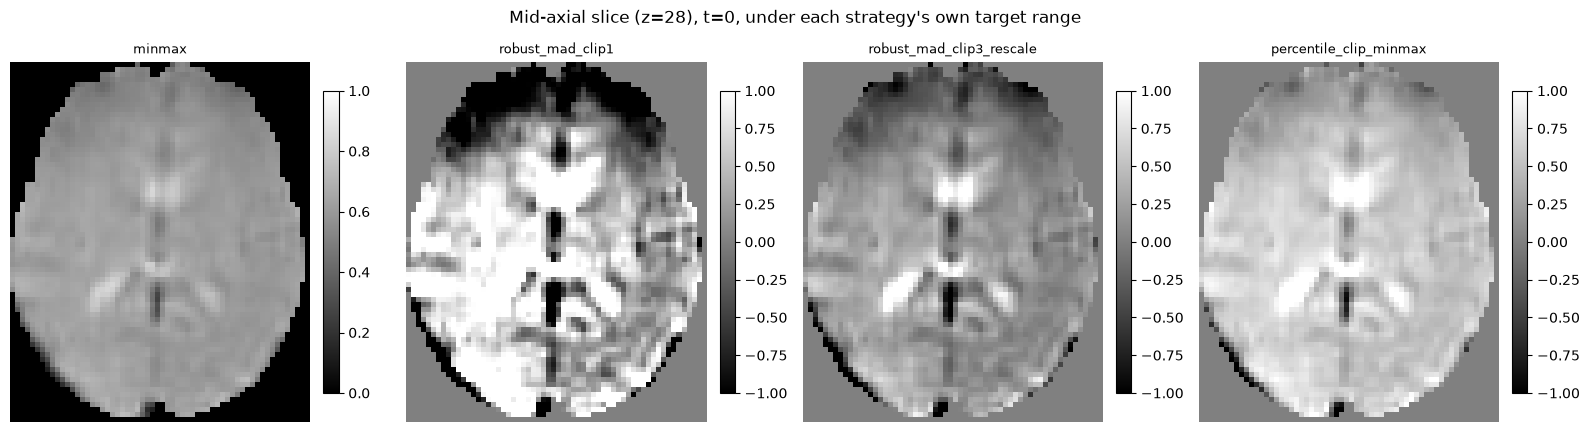

In [10]:
def plot_strategy_montage(data4d, mask, fn, target_range, title, ncols=10, mid_slice_only=False):
    """Applies `fn` to the whole run, then plots either the full axial montage (every Z slice, t=0)
    or just the mid-Z slice, depending on `mid_slice_only`."""
    out, _ = fn(data4d, mask)
    vmin, vmax = target_range
    vol_t0 = out[..., 0]
    if mid_slice_only:
        fig, ax = plt.subplots(figsize=(4, 4.5))
        im = ax.imshow(vol_t0[:, :, vol_t0.shape[2] // 2].T, cmap="gray", vmin=vmin, vmax=vmax, origin="lower")
        ax.set_title(title, fontsize=9)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        return fig
    n_slices = vol_t0.shape[2]
    nrows = int(np.ceil(n_slices / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.2, nrows * 1.5))
    for i, ax in enumerate(axes.flat):
        if i < n_slices:
            ax.imshow(vol_t0[:, :, i].T, cmap="gray", vmin=vmin, vmax=vmax, origin="lower")
            ax.set_title(str(i), fontsize=6)
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    return fig


# Quick side-by-side, mid-slice only, for the four most relevant strategies.
compare_strategies = ["minmax", "robust_mad_clip1", "robust_mad_clip3_rescale", "percentile_clip_minmax"]
fig, axes = plt.subplots(1, len(compare_strategies), figsize=(4 * len(compare_strategies), 4.5))
mid_z = data.shape[2] // 2
for ax, name in zip(axes, compare_strategies):
    fn, target = STRATEGIES[name]
    out, _ = fn(data, brain_mask)
    vmin, vmax = (0, 1) if name == "minmax" else (-1, 1)
    im = ax.imshow(out[:, :, mid_z, 0].T, cmap="gray", vmin=vmin, vmax=vmax, origin="lower")
    ax.set_title(name, fontsize=9)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"Mid-axial slice (z={mid_z}), t=0, under each strategy's own target range")
fig.tight_layout()
plt.show()

Full axial montage (every Z slice, t=0) for the recommended strategy -- same style as the earlier
`plot_montage_along_axis` from `dataset_creation.ipynb`, to sanity-check the whole crop, not just
one slice.

In [ ]:
fig = plot_strategy_montage(
    data, brain_mask, strat_robust_mad_clip3_rescale, (-1, 1),
    "robust_mad_clip3_rescale -- full axial montage, t=0",
)
plt.show()

## Denormalization

Inverting `robust_mad_clip3_rescale` means undoing each step in reverse: `* 3` to go from `[-1,1]`
back to `[-3,3]`, then `* scale + median` to go from robust-z-score back to raw intensity.

This is only an **exact** inverse for voxels that weren't clipped in the forward pass. Any voxel
whose true `z = (x - median) / scale` was already beyond `+-3` gets saturated to `output = +-1` --
and `+1` alone can't tell you whether the original `z` was `3.01` or `50`, so denormalizing that
voxel only recovers the clip boundary (`3 * scale + median`), not the true original value. This is
the accepted cost of using a clip at all -- unlike the unclipped `robust_normalize()` from
`dataset_creation.ipynb`, which was exactly invertible for every voxel.

In [ ]:
def denormalize_robust_mad_clip3(output, median, scale, clip_bound=3.0):
    """Inverse of strat_robust_mad_clip3_rescale. Exact for voxels that weren't clipped in the
    forward pass; voxels that saturated to +-1 only recover the clip boundary, not the true value."""
    z_reconstructed = output * clip_bound
    return z_reconstructed * scale + median


out, params = strat_robust_mad_clip3_rescale(data, brain_mask)
x_reconstructed = denormalize_robust_mad_clip3(out[brain_mask], params["median"], params["scale"], params["clip_bound"])
x_original = data[brain_mask]

# Which voxels actually got clipped in the forward pass? (their z was beyond +-3)
z = (x_original - params["median"]) / params["scale"]
was_clipped = (z < -params["clip_bound"]) | (z > params["clip_bound"])
print(f"brain voxels saturated by the clip (not exactly invertible): {was_clipped.mean():.2%}")

abs_err_unclipped = np.abs(x_reconstructed[~was_clipped] - x_original[~was_clipped])
print(f"\nfor the {(~was_clipped).mean():.1%} of voxels that were NOT clipped:")
print(f"  round-trip max abs error: {abs_err_unclipped.max():.3e}")
print(f"  round-trip mean abs error: {abs_err_unclipped.mean():.3e}")
print(f"  exact to floating-point precision: {np.allclose(x_reconstructed[~was_clipped], x_original[~was_clipped])}")

abs_err_clipped = np.abs(x_reconstructed[was_clipped] - x_original[was_clipped])
print(f"\nfor the {was_clipped.mean():.1%} of voxels that WERE clipped:")
print(f"  reconstructed value is just the clip boundary -- mean abs error: {abs_err_clipped.mean():.1f}")
print(f"  (this is expected and permanent information loss, not a bug)")

## Conclusion: `robust_mad_clip3_rescale` is a solid bounded option

Based on the numbers actually produced by this run (subject ICC103A, videos run 001, 485
timepoints, 46.8% brain voxels):

**Robustness test** (corrupting 2% of brain voxels at one timepoint with an 8x-max intensity
spike) is the deciding evidence:

| Strategy | Parameter shift under corruption |
|---|---|
| `minmax` | `hi` (max) jumped **+700%** -- a single corrupted timepoint would compress all 484 other legitimate timepoints into a tiny sliver near 0 |
| `zscore` | `std` inflated **+15.3%** -- a real, non-trivial distortion |
| `robust_p5p95` | **~0.0%** change |
| `robust_mad` | **~0.0%** change |
| `percentile_clip_minmax` | **~0.0%** change |

`minmax` is disqualified outright -- it's catastrophically sensitive to exactly the kind of
artifact this dataset is full of. `zscore` is meaningfully better but still reacts. The three
robust methods (`p5p95`, `mad`, `percentile_clip`) are all essentially immune to a small-fraction
outlier, which is the property that actually matters for a motion-correction dataset: normalization
shouldn't itself vary with how much motion happened.

**Among the robust, bounded options**, `robust_mad_clip3_rescale` wins on two further points:

- **Not oversaturated**: `robust_mad_clip1` (hard-clipping straight MAD-normalized values to
  `[-1,1]`) saturates ~32% of brain voxels to the exact boundary value -- visually this showed up
  as large flat white/black blobs in the montage, destroying real anatomical contrast.
  `clip3_rescale` only saturates **4.93%** of voxels (everything beyond 3 robust-sigma; confirmed
  directly above), preserving detail for the other ~95%.
- **More symmetric / better dynamic range usage**: skew dropped from -1.83 (raw data) to -0.62 for
  `clip3_rescale`, vs -1.58 for `percentile_clip_minmax` -- `clip3_rescale`'s distribution is
  noticeably closer to symmetric around 0, and it has a higher std (0.389 vs 0.338), meaning it
  uses more of the available `[-1,1]` range rather than leaving it mostly empty.

**Denormalization caveat**: exact (floating-point precision) for the ~95% of voxels that weren't
clipped; for the ~4.93% that were, denormalizing only recovers the clip boundary, not the true
original value -- a permanent, accepted information loss.

This would be the right choice **if** the generator's output were `Tanh`-bounded. But see the next
section -- for this project's actual architecture, it isn't.

## Chosen strategy: `robust_p5p95` (unclipped)

Since the generator uses `use_residual=True` (`models3D/networks.py:545-546` -- `Tanh` is only
appended to the decoder when `use_residual=False`), the final output `input + correction` is
**never bounded to `[-1, 1]`** by the architecture. That removes the whole reason to clip the
normalized input, so an **unclipped** robust normalization becomes a legitimate choice: zero
information loss (every voxel denormalizes exactly, not just the ~95% that survive `clip3_rescale`),
while remaining just as robust to motion-spike corruption as the clipped version (confirmed
~0.0% parameter shift in the robustness test above).

`robust_p5p95` (over unclipped `robust_mad`) for its narrower natural range -- on this run
`[-2.28, 1.62]` vs. `robust_mad`'s `[-10.13, 7.21]` -- keeping typical values closer to unit scale
without needing to clip anything away.

In [5]:
data.shape, brain_mask.shape

((60, 72, 56, 485), (60, 72, 56))

In [8]:
def denormalize_robust_p5p95(z, median, scale):
    """Exact inverse of strat_robust_p5p95 -- unclipped, so this recovers every voxel exactly."""
    return z * scale + median


fmri_normalized_p5p95, p5p95_params = strat_robust_p5p95(data, brain_mask)
median, scale = p5p95_params["median"], p5p95_params["scale"]

x_original = data[brain_mask]
x_reconstructed = denormalize_robust_p5p95(fmri_normalized_p5p95[brain_mask], median, scale)
abs_err = np.abs(x_reconstructed - x_original)

print(f"median = {median:.3f}, scale (p95-p5) = {scale:.3f}")
print(f"normalized brain-voxel range: [{fmri_normalized_p5p95[brain_mask].min():.3f}, {fmri_normalized_p5p95[brain_mask].max():.3f}]")
print(f"round-trip max abs error (ALL brain voxels -- no clipping, nothing excluded): {abs_err.max():.3e}")
print(f"round-trip mean abs error: {abs_err.mean():.3e}")
print(f"round-trip error is at float32 precision level (max value ~{data[brain_mask].max():.0f}, "
      f"so ~1e-5 absolute error here is expected rounding noise, not a bug)")

median = 346.849, scale (p95-p5) = 151.977
normalized brain-voxel range: [-2.278, 1.620]
round-trip max abs error (ALL brain voxels -- no clipping, nothing excluded): 4.578e-05
round-trip mean abs error: 1.039e-07
round-trip error is at float32 precision level (max value ~593, so ~1e-5 absolute error here is expected rounding noise, not a bug)


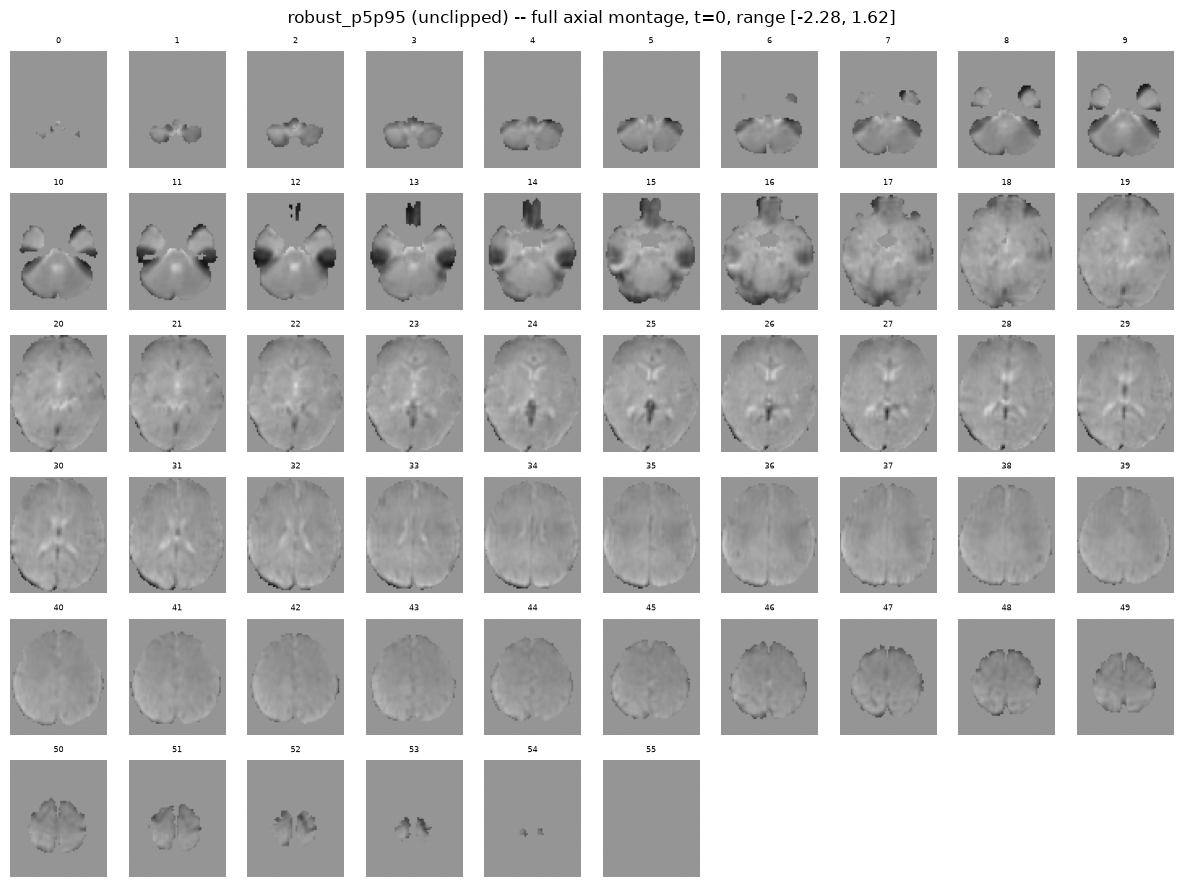

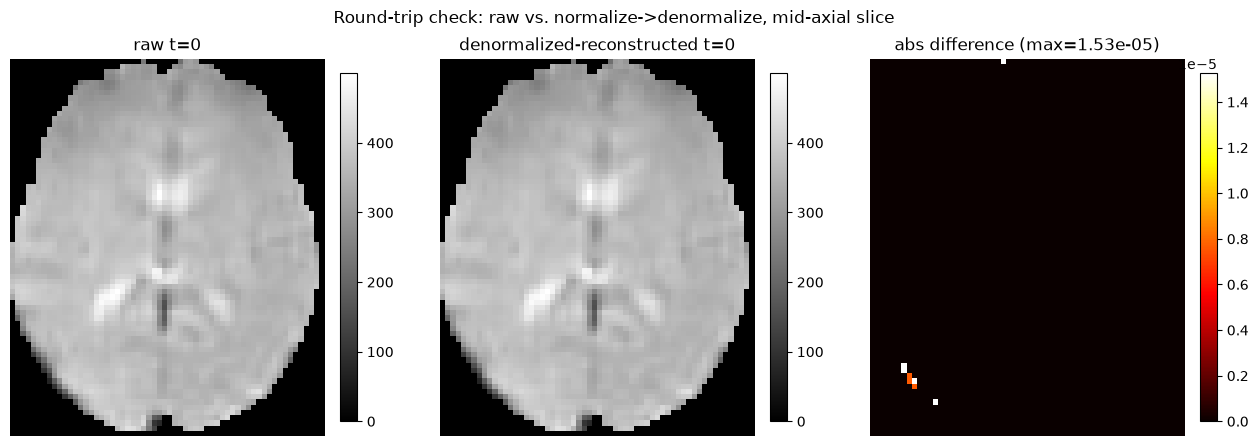

In [11]:
vmin, vmax = fmri_normalized_p5p95[brain_mask].min(), fmri_normalized_p5p95[brain_mask].max()

fig = plot_strategy_montage(
    data, brain_mask, strat_robust_p5p95, (vmin, vmax),
    f"robust_p5p95 (unclipped) -- full axial montage, t=0, range [{vmin:.2f}, {vmax:.2f}]",
)
plt.show()

# Sanity check: raw t=0 vs. denormalized-reconstructed t=0 -- should be visually and numerically identical.
t0_denorm = np.zeros_like(data[..., 0])
t0_denorm[brain_mask] = denormalize_robust_p5p95(fmri_normalized_p5p95[..., 0][brain_mask], median, scale)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
mid_z = data.shape[2] // 2
im0 = axes[0].imshow(data[:, :, mid_z, 0].T, cmap="gray", origin="lower")
axes[0].set_title("raw t=0")
im1 = axes[1].imshow(t0_denorm[:, :, mid_z].T, cmap="gray", origin="lower")
axes[1].set_title("denormalized-reconstructed t=0")
diff = np.abs(t0_denorm[:, :, mid_z] - data[:, :, mid_z, 0])
im2 = axes[2].imshow(diff.T, cmap="hot", origin="lower")
axes[2].set_title(f"abs difference (max={diff.max():.2e})")
for ax, im in zip(axes, [im0, im1, im2]):
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Round-trip check: raw vs. normalize->denormalize, mid-axial slice")
fig.tight_layout()
plt.show()